# Tomato Leaf Disease Classification — Attention Mechanism Ablation Study

**Backbone:** MobileNetV3Large (ImageNet pretrained)
**Dataset:** `yusufmurtaza01/tomato-leaf-disease` (YOLO-format, converted to classification folders)

This notebook trains and evaluates 5 model variants on the same data pipeline for a fair comparison:

1. **Baseline** — MobileNetV3Large, frozen backbone
2. **CA** — Baseline + Channel Attention
3. **SA** — Baseline + Spatial Attention
4. **CBAM** — Baseline + Channel + Spatial Attention (CBAM block)
5. **HECA** — CBAM + selective fine-tuning of the last 30 backbone layers

For every model this notebook produces: a classification report, confusion matrix, accuracy/loss curves, and a multiclass ROC curve, then rolls everything into a single comparison table and a downloadable zip of all artifacts.

> **Kaggle setup:** add the `yusufmurtaza01/tomato-leaf-disease` dataset via *Add Input* before running, and turn on a **GPU accelerator** (Settings → Accelerator) — training 5 models will be slow on CPU.


## 1. Imports & Environment Check

In [1]:
import os
import gc
import yaml
import shutil
import zipfile

import numpy as np
import pandas as pd
import tensorflow as tf

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU(s) detected: {[g.name for g in gpus]}")
else:
    print("No GPU detected — go to Settings > Accelerator and enable a GPU for reasonable training times.")


TensorFlow: 2.20.0
Keras: 3.13.2
GPU(s) detected: ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 2. Configuration

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-3
HECA_LEARNING_RATE = 1e-4          # lower LR since HECA fine-tunes backbone layers
HECA_UNFROZEN_LAYERS = 30          # last N backbone layers unfrozen for HECA

FORCE_RETRAIN = False               # set True to ignore existing checkpoints and retrain everything from scratch

WORK_DIR = "/kaggle/working"
DATA_DIR = "/kaggle/working/tomato_classification"

os.makedirs(WORK_DIR, exist_ok=True)

# Running list that the final comparison table/plots are built from
comparison_results = []
histories = {}   # model_name -> keras History (or resumed history), for the overlay plots at the end


## 3. Locate the Dataset

On Kaggle the dataset should be attached via **Add Input** (search `tomato-leaf-disease` by `yusufmurtaza01`), which mounts it read-only under `/kaggle/input/...`. This cell searches `/kaggle/input` for `data.yaml` first; if it isn't found (e.g. running outside Kaggle, or the dataset wasn't attached) it falls back to `kagglehub`.

In [7]:
yaml_path = None

for root, dirs, files in os.walk("/kaggle/input"):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

if yaml_path is None:
    print("data.yaml not found under /kaggle/input — falling back to kagglehub download.")
    import kagglehub
    dataset_root = kagglehub.dataset_download("yusufmurtaza01/tomato-leaf-disease")
    for root, dirs, files in os.walk(dataset_root):
        if "data.yaml" in files:
            yaml_path = os.path.join(root, "data.yaml")
            break

assert yaml_path is not None, "Could not locate data.yaml — check the dataset is attached."
print("Using data.yaml at:", yaml_path)

DATASET_ROOT = os.path.dirname(yaml_path)


Using data.yaml at: /kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato/data.yaml


In [8]:
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml["names"]
NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
for idx, cls in enumerate(CLASS_NAMES):
    print(idx, "->", cls)


Number of classes: 10
0 -> Tomato__BacterialSpot
1 -> Tomato__EarlyBlight
2 -> Tomato__Healthy
3 -> Tomato__LateBlight
4 -> Tomato__LeafMold
5 -> Tomato__MosaicVirus
6 -> Tomato__SeptoriaLeafSpot
7 -> Tomato__SpiderMites
8 -> Tomato__TargetSpot
9 -> Tomato__YellowLeafCurlVirus


## 4. Convert YOLO-format Dataset to Classification Folders

In [9]:
IMG_TRAIN = os.path.join(DATASET_ROOT, "images/train")
IMG_VAL   = os.path.join(DATASET_ROOT, "images/val")
LBL_TRAIN = os.path.join(DATASET_ROOT, "labels/train")
LBL_VAL   = os.path.join(DATASET_ROOT, "labels/val")

print("Train images:", IMG_TRAIN, "| exists:", os.path.exists(IMG_TRAIN))
print("Val images:  ", IMG_VAL,   "| exists:", os.path.exists(IMG_VAL))

for split in ["train", "val"]:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(DATA_DIR, split, cls), exist_ok=True)

print("Classification folders ready at:", DATA_DIR)


Train images: /kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato/images/train | exists: True
Val images:   /kaggle/input/datasets/yusufmurtaza01/tomato-leaf-disease/tomato/images/val | exists: True
Classification folders ready at: /kaggle/working/tomato_classification


In [10]:
def convert_split(img_dir, lbl_dir, split):
    """Copy each YOLO image into DATA_DIR/<split>/<class_name>/ based on its label file's first class id."""
    images = os.listdir(img_dir)
    copied = 0

    for img_file in tqdm(images, desc=f"Converting {split}"):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(lbl_dir, label_file)

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            line = f.readline().strip()

        if line == "":
            continue

        class_id = int(line.split()[0])
        class_name = CLASS_NAMES[class_id]

        src = os.path.join(img_dir, img_file)
        dst = os.path.join(DATA_DIR, split, class_name, img_file)
        shutil.copy2(src, dst)
        copied += 1

    print(f"{split} copied: {copied}")


convert_split(IMG_TRAIN, LBL_TRAIN, "train")
convert_split(IMG_VAL, LBL_VAL, "val")
print("CONVERSION COMPLETE")


Converting train: 100%|██████████| 12168/12168 [01:16<00:00, 158.20it/s]


train copied: 12168


Converting val: 100%|██████████| 3041/3041 [00:19<00:00, 159.78it/s]

val copied: 3041
CONVERSION COMPLETE


In [11]:
for cls in CLASS_NAMES:
    train_count = len(os.listdir(os.path.join(DATA_DIR, "train", cls)))
    val_count = len(os.listdir(os.path.join(DATA_DIR, "val", cls)))
    print(f"{cls:25s} | Train: {train_count:5d} | Val: {val_count:5d}")


Tomato__BacterialSpot     | Train:  1598 | Val:   400
Tomato__EarlyBlight       | Train:   870 | Val:   218
Tomato__Healthy           | Train:  1322 | Val:   332
Tomato__LateBlight        | Train:  1599 | Val:   400
Tomato__LeafMold          | Train:   834 | Val:   208
Tomato__MosaicVirus       | Train:   342 | Val:    85
Tomato__SeptoriaLeafSpot  | Train:  1536 | Val:   383
Tomato__SpiderMites       | Train:  1343 | Val:   335
Tomato__TargetSpot        | Train:  1124 | Val:   280
Tomato__YellowLeafCurlVirus | Train:  1600 | Val:   400


## 5. Load `tf.data` Datasets

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,          # keep val order fixed so y_true lines up with predictions
    label_mode="int"
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 12168 files belonging to 10 classes.


I0000 00:00:1785418327.618354      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785418327.621264      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3041 files belonging to 10 classes.
Classes: ['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(5000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

print("Datasets cached/prefetched")


Datasets cached/prefetched


In [14]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())


Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Min pixel: 0.0
Max pixel: 252.3215


## 6. Data Augmentation

The same augmentation pipeline is used for every model variant so the comparison isn't confounded by different preprocessing.

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Augmentation pipeline ready")


Augmentation pipeline ready


## 7. Attention Modules

`spatial_attention` uses named, `@register_keras_serializable` functions (instead of anonymous lambdas) so the saved `.keras` models reload cleanly in a fresh kernel — plain closures over `tf.reduce_mean`/`tf.reduce_max` are a common source of `Lambda` deserialization errors when a model is reloaded later (e.g. for the ROC curve step, or in a separate notebook).

In [16]:
def channel_attention(inputs, ratio=8):
    channels = inputs.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(inputs)
    dense1 = tf.keras.layers.Dense(channels // ratio, activation="relu")(avg_pool)
    dense2 = tf.keras.layers.Dense(channels, activation="sigmoid")(dense1)
    scale = tf.keras.layers.Reshape((1, 1, channels))(dense2)

    return tf.keras.layers.Multiply()([inputs, scale])


print("Channel Attention ready")


Channel Attention ready


In [17]:
@tf.keras.utils.register_keras_serializable(package="HECA")
def spatial_avg_pool(x):
    return tf.reduce_mean(x, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable(package="HECA")
def spatial_max_pool(x):
    return tf.reduce_max(x, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable(package="HECA")
def spatial_pool_output_shape(input_shape):
    # NOTE: this also has to be a named, registered function (not an inline
    # lambda) — Keras 3's safe-mode reload check applies to the Lambda
    # layer's `output_shape` argument just as much as its `function`
    # argument. An anonymous lambda here is what actually causes the
    # "Requested the deserialization of a Lambda layer..." ValueError on
    # load_model, even when `function` itself is already registered.
    return (input_shape[0], input_shape[1], input_shape[2], 1)


def spatial_attention(inputs):
    avg_pool = tf.keras.layers.Lambda(
        spatial_avg_pool,
        output_shape=spatial_pool_output_shape
    )(inputs)

    max_pool = tf.keras.layers.Lambda(
        spatial_max_pool,
        output_shape=spatial_pool_output_shape
    )(inputs)

    concat = tf.keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])

    attention = tf.keras.layers.Conv2D(
        1, kernel_size=7, padding="same", activation="sigmoid"
    )(concat)

    return tf.keras.layers.Multiply()([inputs, attention])


print("Spatial Attention ready")


Spatial Attention ready


In [18]:
def cbam_block(inputs):
    x = channel_attention(inputs)
    x = spatial_attention(x)
    return x


print("CBAM Block ready")


CBAM Block ready


## 8. Reusable Training / Evaluation Helpers

Every model variant below just calls these four functions, so the pipeline stays identical across models (fair comparison) and the notebook doesn't repeat the same 40 lines five times.

In [19]:
def build_model(attention_fn=None, fine_tune_layers=0, learning_rate=LEARNING_RATE, name="model"):
    """Build a MobileNetV3Large classifier, optionally with an attention block and/or
    a partially unfrozen backbone (fine_tune_layers > 0 unfreezes the last N backbone layers)."""
    base_model = MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )

    if fine_tune_layers > 0:
        for layer in base_model.layers[:-fine_tune_layers]:
            layer.trainable = False
        for layer in base_model.layers[-fine_tune_layers:]:
            layer.trainable = True
        backbone_training_mode = True
    else:
        base_model.trainable = False
        backbone_training_mode = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=backbone_training_mode)

    if attention_fn is not None:
        x = attention_fn(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    non_trainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    print(f"[{name}] Trainable params: {trainable:,} | Non-trainable params: {non_trainable:,}")

    return model, base_model


def make_callbacks(prefix):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            f"{WORK_DIR}/best_{prefix}_model.keras",
            monitor="val_accuracy",
            save_best_only=True,
            verbose=0
        ),
        tf.keras.callbacks.CSVLogger(f"{WORK_DIR}/{prefix}_training_log.csv")
    ]


class _ResumedHistory:
    """Minimal stand-in for a Keras History object, built from a saved CSVLogger
    file, so already-trained models slot into plot_training_curves() and the
    final overlay plots exactly like a freshly-fit model would."""
    def __init__(self, history_dict):
        self.history = history_dict


def train_or_resume(model, prefix, model_name, epochs=EPOCHS):
    """Train a model, unless a checkpoint + training log for `prefix` already
    exist on disk (e.g. from a previous run of this same notebook) — in that
    case, training is skipped entirely and the history is reconstructed from
    the saved log instead. This protects already-completed models (like a
    finished Baseline/CA run) from being silently retrained and overwritten
    if you have to re-run cells after fixing something downstream.

    Set FORCE_RETRAIN = True in the config cell to always retrain regardless.
    """
    ckpt_path = f"{WORK_DIR}/best_{prefix}_model.keras"
    log_path = f"{WORK_DIR}/{prefix}_training_log.csv"

    if (not FORCE_RETRAIN) and os.path.exists(ckpt_path) and os.path.exists(log_path):
        print(f"[{model_name}] Existing checkpoint + log found — skipping training and reusing the previous run.")
        print(f"  Checkpoint: {ckpt_path}")
        print(f"  Log:        {log_path}")
        log_df = pd.read_csv(log_path)
        history_dict = {col: log_df[col].tolist() for col in log_df.columns if col != "epoch"}
        return _ResumedHistory(history_dict)

    print(f"[{model_name}] Training from scratch for up to {epochs} epochs...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=make_callbacks(prefix)
    )
    return history


def plot_training_curves(history, model_name, prefix):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train")
    plt.plot(history.history["val_accuracy"], label="Val")
    plt.title(f"{model_name} — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train")
    plt.plot(history.history["val_loss"], label="Val")
    plt.title(f"{model_name} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{WORK_DIR}/{prefix}_training_curves.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def evaluate_model(model, model_name, prefix, y_true, class_names):
    """Runs prediction + classification report + confusion matrix, returns (probs, comparison_row)."""
    probs = model.predict(val_ds, verbose=1)
    preds = np.argmax(probs, axis=1)

    report_str = classification_report(y_true, preds, target_names=class_names)
    print(report_str)

    report_dict = classification_report(y_true, preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report_dict).transpose().to_csv(f"{WORK_DIR}/{prefix}_classification_report.csv")

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"{WORK_DIR}/{prefix}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    row = {
        "Model": model_name,
        "Accuracy": report_dict["accuracy"],
        "Macro_F1": report_dict["macro avg"]["f1-score"],
        "Weighted_F1": report_dict["weighted avg"]["f1-score"],
    }

    return probs, row


def plot_roc_curve(probs, y_true_bin, class_names, model_name, prefix):
    plt.figure(figsize=(10, 8))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(fontsize=7, loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{WORK_DIR}/{prefix}_roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def cleanup(*objs):
    for name in objs:
        if name in globals():
            del globals()[name]
    gc.collect()
    tf.keras.backend.clear_session()


print("Helpers ready")


Helpers ready


### Ground truth labels (computed once, reused for every model's evaluation + ROC curve)

In [20]:
y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

print("y_true shape:", y_true.shape)
print("y_true_bin shape:", y_true_bin.shape)


y_true shape: (3041,)
y_true_bin shape: (3041, 10)


## 9. Model 1 — Baseline MobileNetV3Large (frozen backbone, no attention)

In [21]:
baseline_model, baseline_backbone = build_model(
    attention_fn=None,
    fine_tune_layers=0,
    learning_rate=LEARNING_RATE,
    name="baseline"
)
baseline_model.summary()


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[baseline] Trainable params: 9,610 | Non-trainable params: 2,996,352


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         9,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,005,962 (11.47 MB)

 Trainable params: 9,610 (37.54 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [22]:
baseline_history = train_or_resume(baseline_model, "baseline", "Baseline")

histories["Baseline"] = baseline_history


[Baseline] Training from scratch for up to 50 epochs...
Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.6202 - loss: 1.1558 - val_accuracy: 0.8139 - val_loss: 0.6511
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.7931 - loss: 0.6515 - val_accuracy: 0.8471 - val_loss: 0.5331
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8292 - loss: 0.5419 - val_accuracy: 0.8520 - val_loss: 0.4917
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.8390 - loss: 0.5064 - val_accuracy: 0.8685 - val_loss: 0.4585
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8497 - loss: 0.4789 - val_accuracy: 0.8787 - val_loss: 0.4235
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8561 - loss: 0.4450 - val_accuracy: 0.8619 - val_loss: 0.4561
Epoch 7/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8576 - loss: 0.4394 - val_accuracy: 0.8714 - val_loss: 0.4377
Epoch 8/50
381/381 ━━━━━━━━━━━━━━━

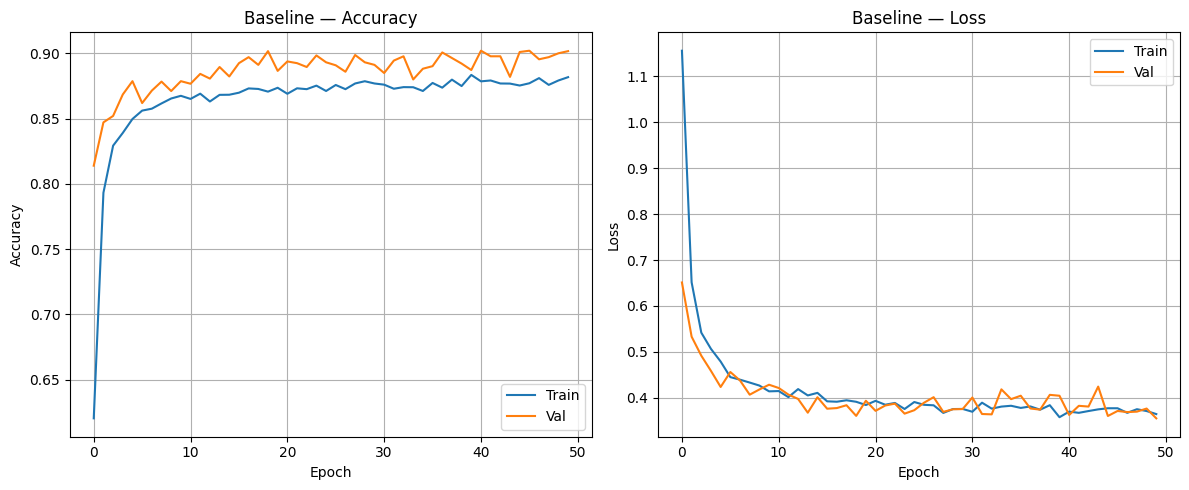

96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step
                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.94      0.88      0.91       400
        Tomato__EarlyBlight       0.91      0.72      0.81       218
            Tomato__Healthy       0.92      0.98      0.94       332
         Tomato__LateBlight       0.88      0.97      0.93       400
           Tomato__LeafMold       0.91      0.88      0.89       208
        Tomato__MosaicVirus       0.96      0.78      0.86        85
   Tomato__SeptoriaLeafSpot       0.87      0.90      0.88       383
        Tomato__SpiderMites       0.87      0.92      0.89       335
         Tomato__TargetSpot       0.82      0.88      0.85       280
Tomato__YellowLeafCurlVirus       0.99      0.94      0.96       400

                   accuracy                           0.90      3041
                  macro avg       0.91      0.88      0.89      3041
               weighted avg       0.90      0.90      0.90   

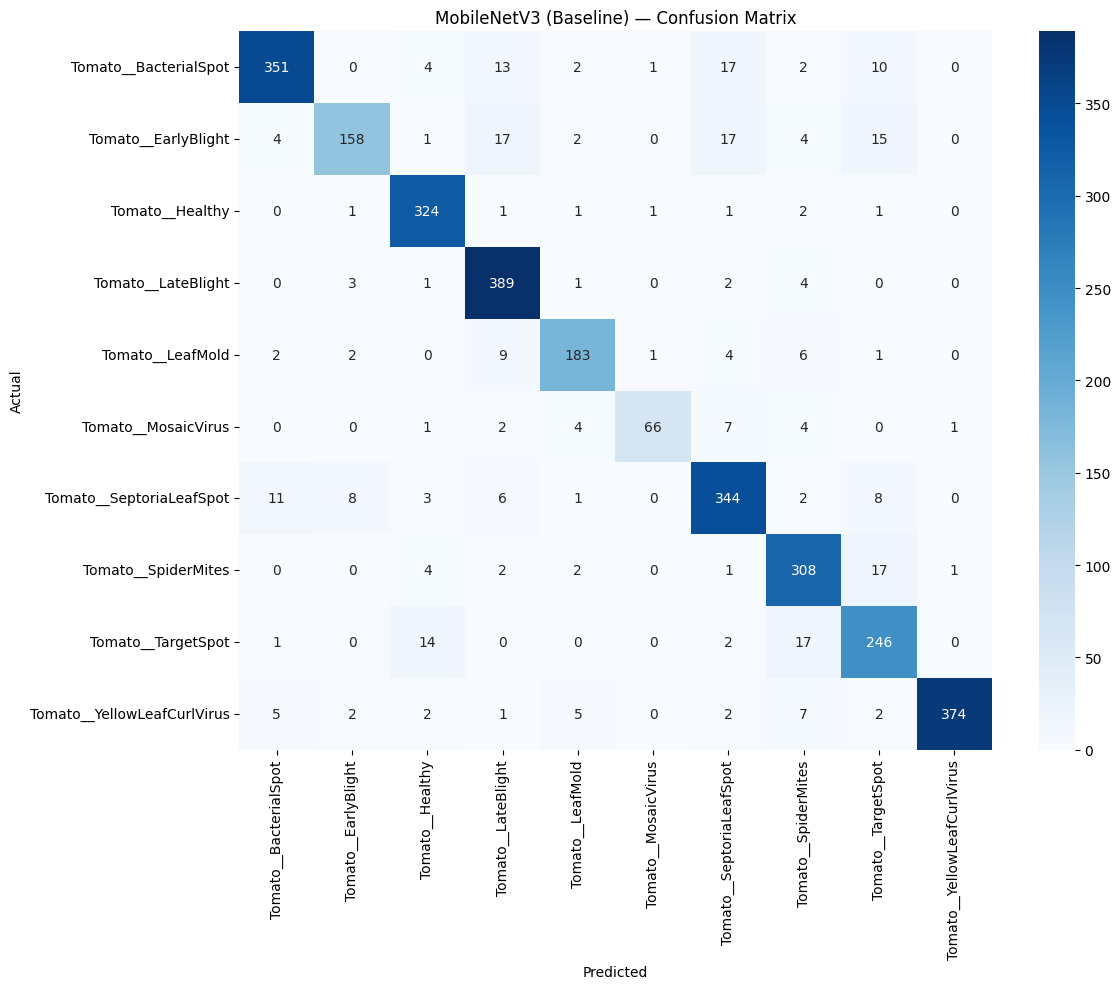

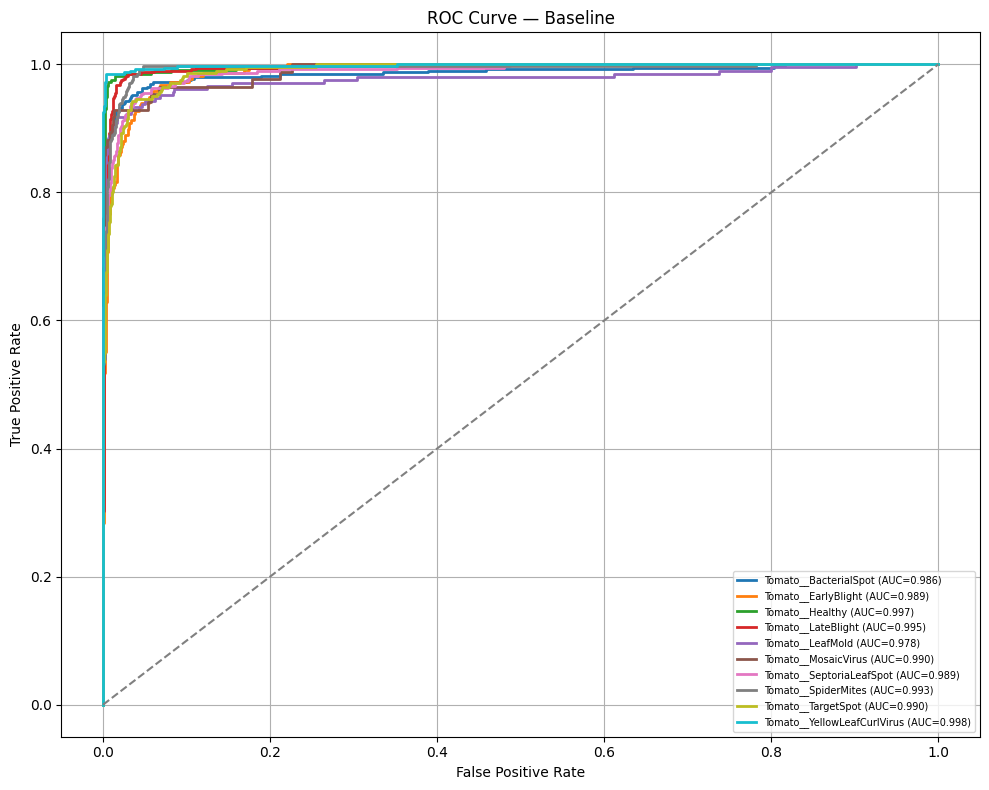

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397


In [23]:
plot_training_curves(baseline_history, "Baseline", "baseline")

best_baseline_model = tf.keras.models.load_model(f"{WORK_DIR}/best_baseline_model.keras", safe_mode=False)

baseline_probs, baseline_row = evaluate_model(
    best_baseline_model, "MobileNetV3 (Baseline)", "baseline", y_true, class_names
)
comparison_results.append(baseline_row)

plot_roc_curve(baseline_probs, y_true_bin, class_names, "Baseline", "baseline")

pd.DataFrame(comparison_results)


In [ ]:
cleanup("baseline_model", "baseline_backbone")
print("Baseline cleanup complete")


## 10. Model 2 — Channel Attention (CA)

In [24]:
ca_model, ca_backbone = build_model(
    attention_fn=channel_attention,
    fine_tune_layers=0,
    learning_rate=LEARNING_RATE,
    name="ca"
)
ca_model.summary()


[ca] Trainable params: 241,090 | Non-trainable params: 2,996,352


Model: "ca"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 960)       │    116,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 960) │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_16[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      9,610 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,442 (12.35 MB)

 Trainable params: 241,090 (941.76 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [25]:
ca_history = train_or_resume(ca_model, "ca", "Channel Attention (CA)")

histories["CA"] = ca_history


[Channel Attention (CA)] Training from scratch for up to 50 epochs...
Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.7333 - loss: 0.8402 - val_accuracy: 0.8376 - val_loss: 0.4956
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8727 - loss: 0.3910 - val_accuracy: 0.8882 - val_loss: 0.3479
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9011 - loss: 0.3038 - val_accuracy: 0.8754 - val_loss: 0.3674
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9088 - loss: 0.2666 - val_accuracy: 0.8987 - val_loss: 0.3330
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9246 - loss: 0.2259 - val_accuracy: 0.8875 - val_loss: 0.3448
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9310 - loss: 0.2062 - val_accuracy: 0.9165 - val_loss: 0.2772
Epoch 7/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9366 - loss: 0.1847 - val_accuracy: 0.8997 - val_loss: 0.3210
Epoch 8/50
381/381 ━

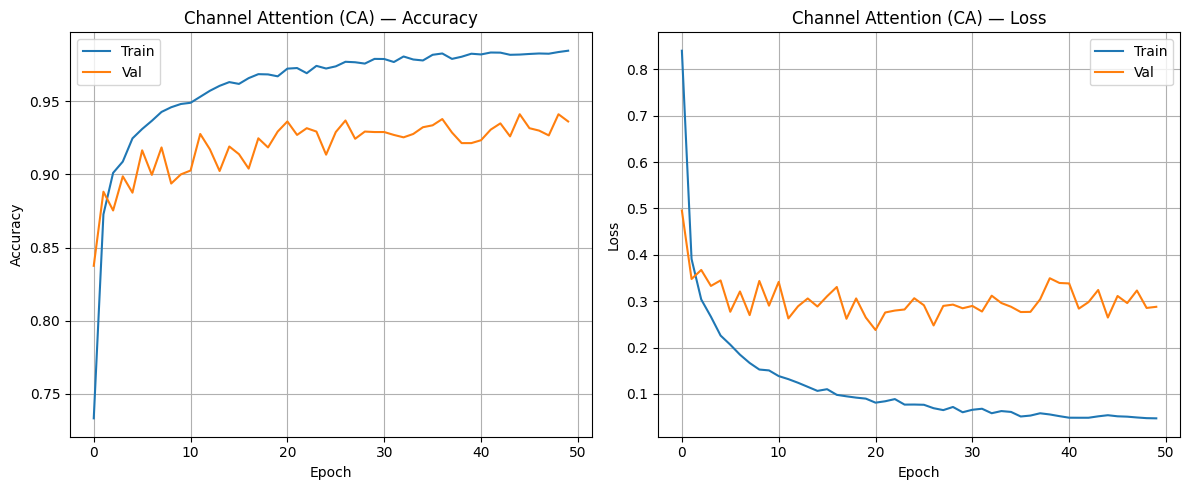

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step
                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.95      0.95      0.95       400
        Tomato__EarlyBlight       0.94      0.84      0.89       218
            Tomato__Healthy       0.95      0.98      0.96       332
         Tomato__LateBlight       0.95      0.95      0.95       400
           Tomato__LeafMold       0.89      0.92      0.90       208
        Tomato__MosaicVirus       0.97      0.81      0.88        85
   Tomato__SeptoriaLeafSpot       0.89      0.95      0.92       383
        Tomato__SpiderMites       0.95      0.94      0.95       335
         Tomato__TargetSpot       0.93      0.94      0.93       280
Tomato__YellowLeafCurlVirus       0.99      0.96      0.98       400

                   accuracy                           0.94      3041
                  macro avg       0.94      0.93      0.93      3041
               weighted avg       0.94      0.94      0.94   

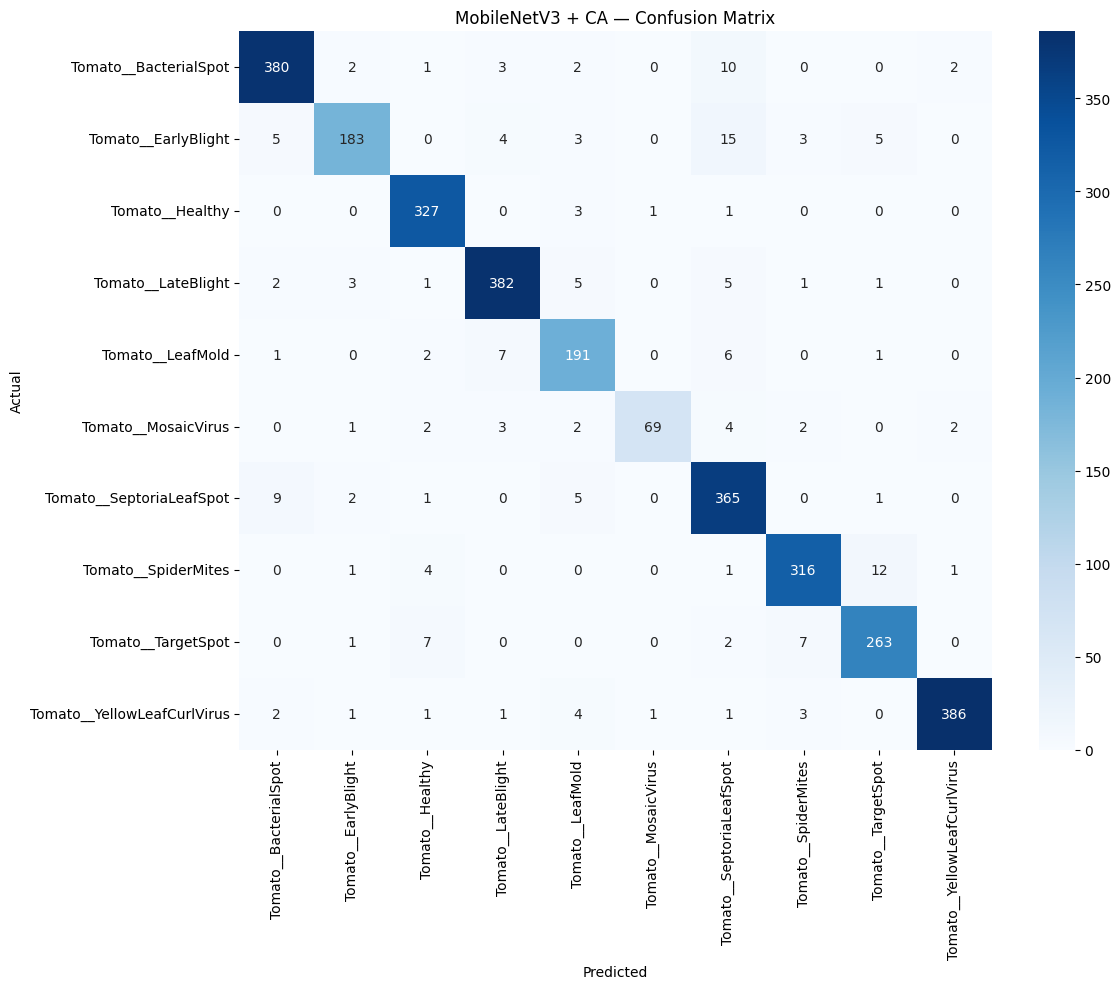

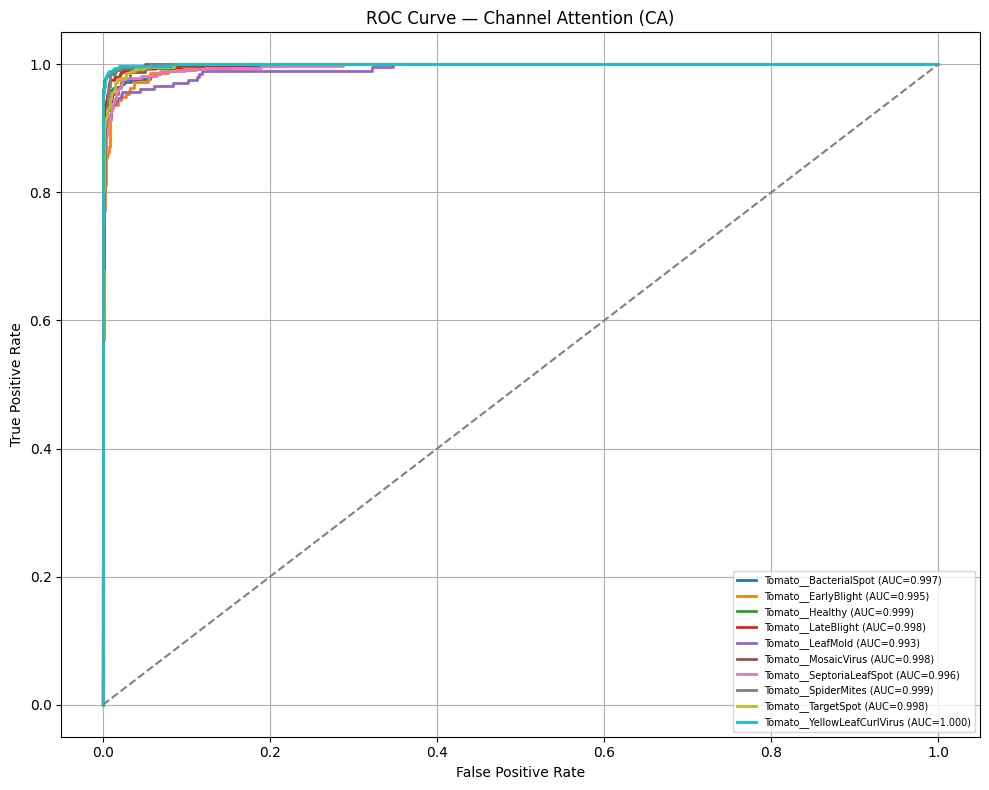

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397
1,MobileNetV3 + CA,0.941138,0.932517,0.940940


In [26]:
plot_training_curves(ca_history, "Channel Attention (CA)", "ca")

best_ca_model = tf.keras.models.load_model(f"{WORK_DIR}/best_ca_model.keras", safe_mode=False)

ca_probs, ca_row = evaluate_model(
    best_ca_model, "MobileNetV3 + CA", "ca", y_true, class_names
)
comparison_results.append(ca_row)

plot_roc_curve(ca_probs, y_true_bin, class_names, "Channel Attention (CA)", "ca")

pd.DataFrame(comparison_results)


In [ ]:
cleanup("ca_model", "ca_backbone")
print("CA cleanup complete")


## 11. Model 3 — Spatial Attention (SA)

In [27]:
sa_model, sa_backbone = build_model(
    attention_fn=spatial_attention,
    fine_tune_layers=0,
    learning_rate=LEARNING_RATE,
    name="sa"
)
sa_model.summary()


[sa] Trainable params: 9,709 | Non-trainable params: 2,996,352


Model: "sa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ MobileNetV3Large… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_25         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_25[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │      9,610 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,006,061 (11.47 MB)

 Trainable params: 9,709 (37.93 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [28]:
sa_history = train_or_resume(sa_model, "sa", "Spatial Attention (SA)")

histories["SA"] = sa_history


[Spatial Attention (SA)] Training from scratch for up to 50 epochs...
Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.6383 - loss: 1.0877 - val_accuracy: 0.8224 - val_loss: 0.6088
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8041 - loss: 0.6200 - val_accuracy: 0.8635 - val_loss: 0.4972
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8364 - loss: 0.5165 - val_accuracy: 0.8520 - val_loss: 0.4964
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8474 - loss: 0.4838 - val_accuracy: 0.8642 - val_loss: 0.4496
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8549 - loss: 0.4628 - val_accuracy: 0.8718 - val_loss: 0.4406
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8566 - loss: 0.4495 - val_accuracy: 0.8810 - val_loss: 0.4185
Epoch 7/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.8588 - loss: 0.4283 - val_accuracy: 0.8698 - val_loss: 0.4340
Epoch 8/50
381/381 ━

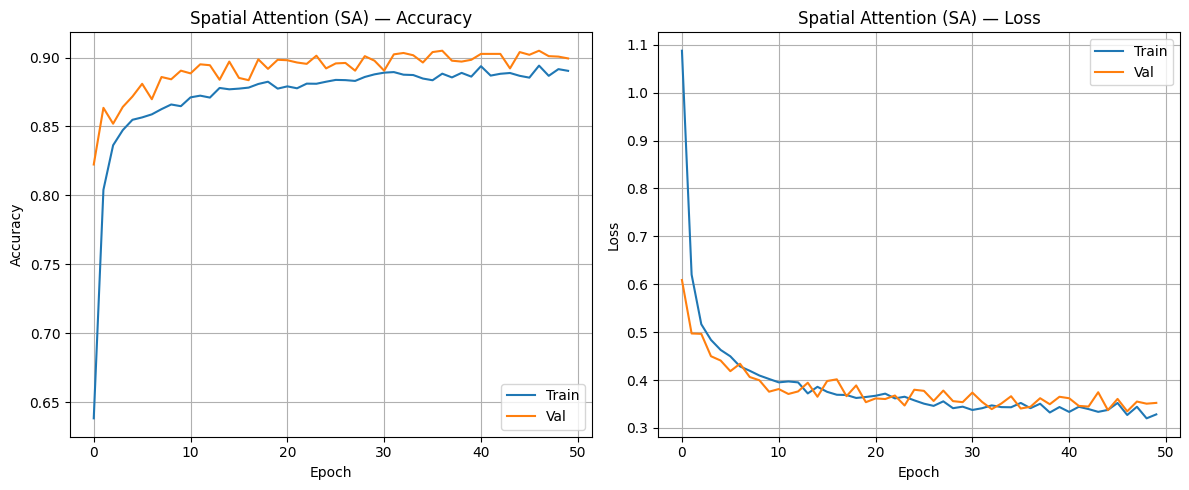

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step
                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.93      0.88      0.90       400
        Tomato__EarlyBlight       0.88      0.76      0.81       218
            Tomato__Healthy       0.90      0.99      0.94       332
         Tomato__LateBlight       0.93      0.96      0.94       400
           Tomato__LeafMold       0.92      0.88      0.90       208
        Tomato__MosaicVirus       0.98      0.71      0.82        85
   Tomato__SeptoriaLeafSpot       0.84      0.92      0.88       383
        Tomato__SpiderMites       0.90      0.91      0.90       335
         Tomato__TargetSpot       0.83      0.88      0.85       280
Tomato__YellowLeafCurlVirus       0.99      0.94      0.97       400

                   accuracy                           0.90      3041
                  macro avg       0.91      0.88      0.89      3041
               weighted avg       0.91      0.90      0.90   

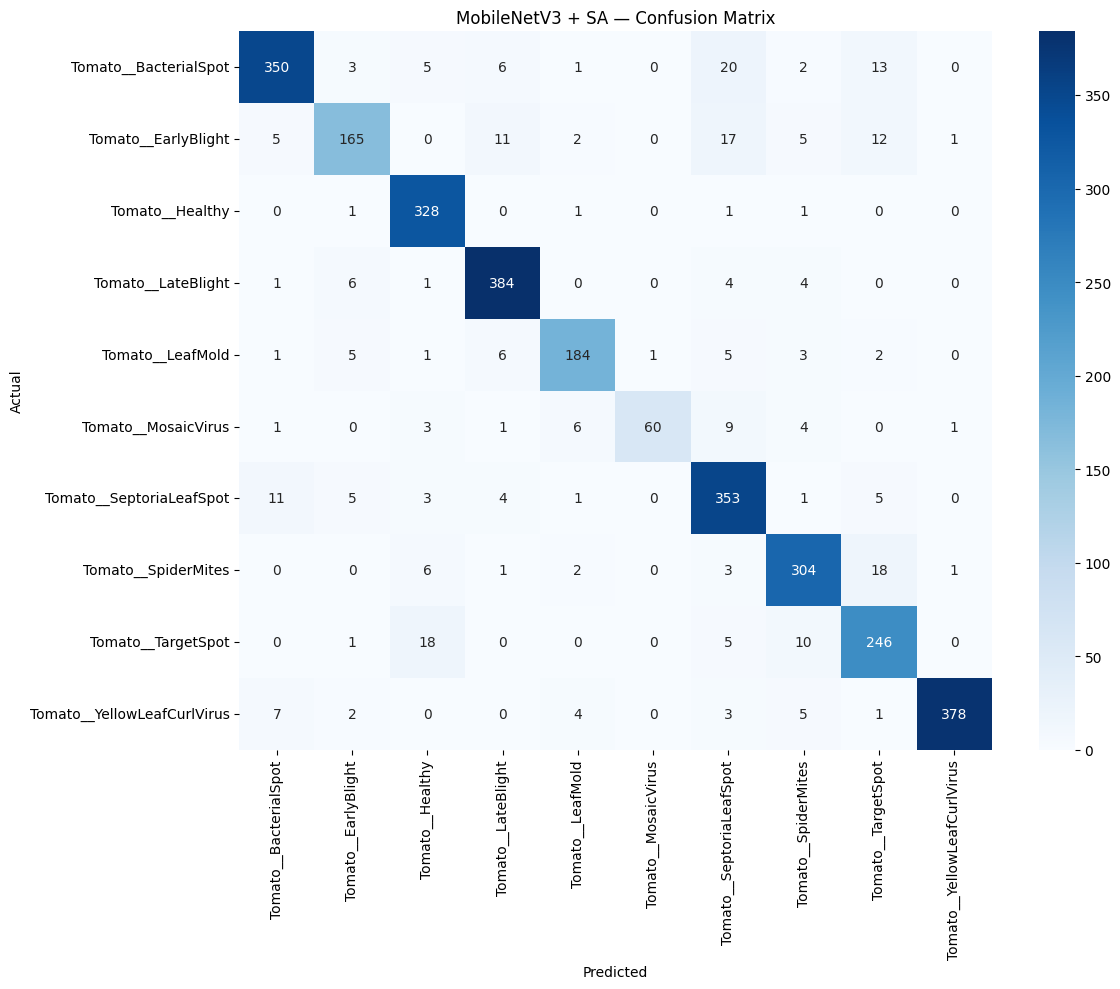

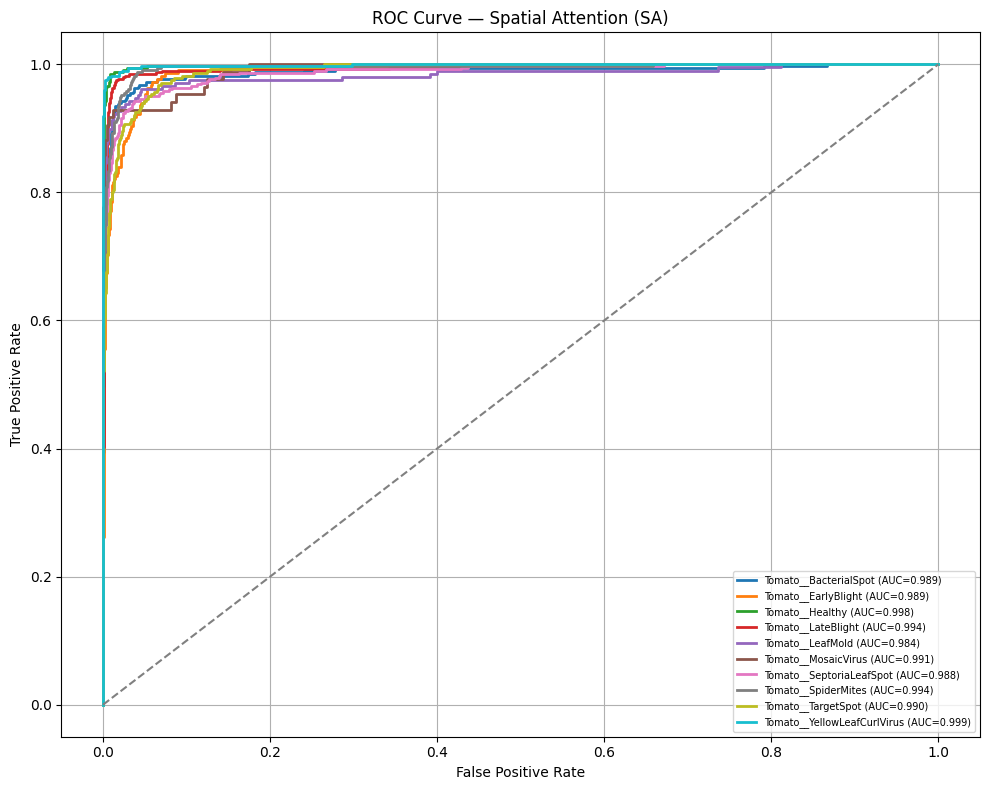

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397
1,MobileNetV3 + CA,0.941138,0.932517,0.940940
2,MobileNetV3 + SA,0.904965,0.892433,0.904386


In [29]:
plot_training_curves(sa_history, "Spatial Attention (SA)", "sa")

best_sa_model = tf.keras.models.load_model(f"{WORK_DIR}/best_sa_model.keras", safe_mode=False)

sa_probs, sa_row = evaluate_model(
    best_sa_model, "MobileNetV3 + SA", "sa", y_true, class_names
)
comparison_results.append(sa_row)

plot_roc_curve(sa_probs, y_true_bin, class_names, "Spatial Attention (SA)", "sa")

pd.DataFrame(comparison_results)


In [ ]:
cleanup("sa_model", "sa_backbone")
print("SA cleanup complete")


## 12. Model 4 — CBAM (Channel + Spatial Attention)

In [30]:
cbam_model, cbam_backbone = build_model(
    attention_fn=cbam_block,
    fine_tune_layers=0,
    learning_rate=LEARNING_RATE,
    name="cbam"
)
cbam_model.summary()


[cbam] Trainable params: 241,189 | Non-trainable params: 2,996,352


Model: "cbam"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 960)       │    116,160 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 960) │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_34         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_34[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_34[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 7, 2)   │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_35         │ (None, 7, 7, 960) │          0 │ multiply_34[0][0… │
│ (Multiply)          │                   │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_35[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      9,610 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,541 (12.35 MB)

 Trainable params: 241,189 (942.14 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [31]:
cbam_history = train_or_resume(cbam_model, "cbam", "CBAM")

histories["CBAM"] = cbam_history


[CBAM] Training from scratch for up to 50 epochs...
Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - accuracy: 0.7337 - loss: 0.8443 - val_accuracy: 0.8422 - val_loss: 0.4917
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.8729 - loss: 0.3935 - val_accuracy: 0.8813 - val_loss: 0.3811
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9005 - loss: 0.3022 - val_accuracy: 0.8810 - val_loss: 0.3648
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9130 - loss: 0.2638 - val_accuracy: 0.8810 - val_loss: 0.3459
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.9195 - loss: 0.2327 - val_accuracy: 0.9013 - val_loss: 0.2904
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.9311 - loss: 0.2030 - val_accuracy: 0.9125 - val_loss: 0.2817
Epoch 7/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9311 - loss: 0.1966 - val_accuracy: 0.9119 - val_loss: 0.2782
Epoch 8/50
381/381 ━━━━━━━━━━━━━━━━━━━

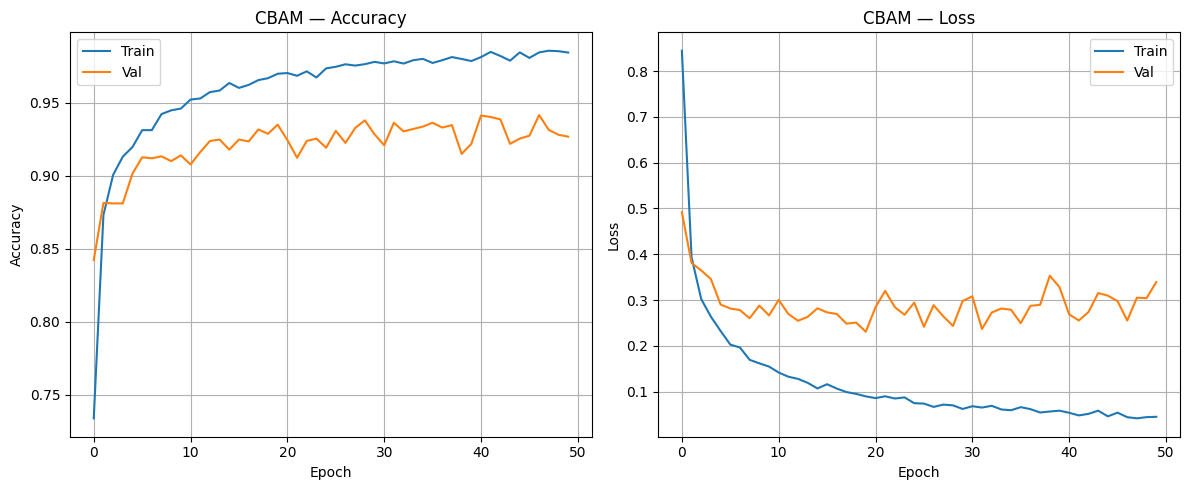

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step
                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.96      0.93      0.95       400
        Tomato__EarlyBlight       0.94      0.83      0.89       218
            Tomato__Healthy       0.96      0.98      0.97       332
         Tomato__LateBlight       0.94      0.98      0.96       400
           Tomato__LeafMold       0.97      0.89      0.93       208
        Tomato__MosaicVirus       0.97      0.86      0.91        85
   Tomato__SeptoriaLeafSpot       0.89      0.95      0.92       383
        Tomato__SpiderMites       0.95      0.94      0.94       335
         Tomato__TargetSpot       0.87      0.94      0.90       280
Tomato__YellowLeafCurlVirus       0.99      0.97      0.98       400

                   accuracy                           0.94      3041
                  macro avg       0.94      0.93      0.94      3041
               weighted avg       0.94      0.94      0.94   

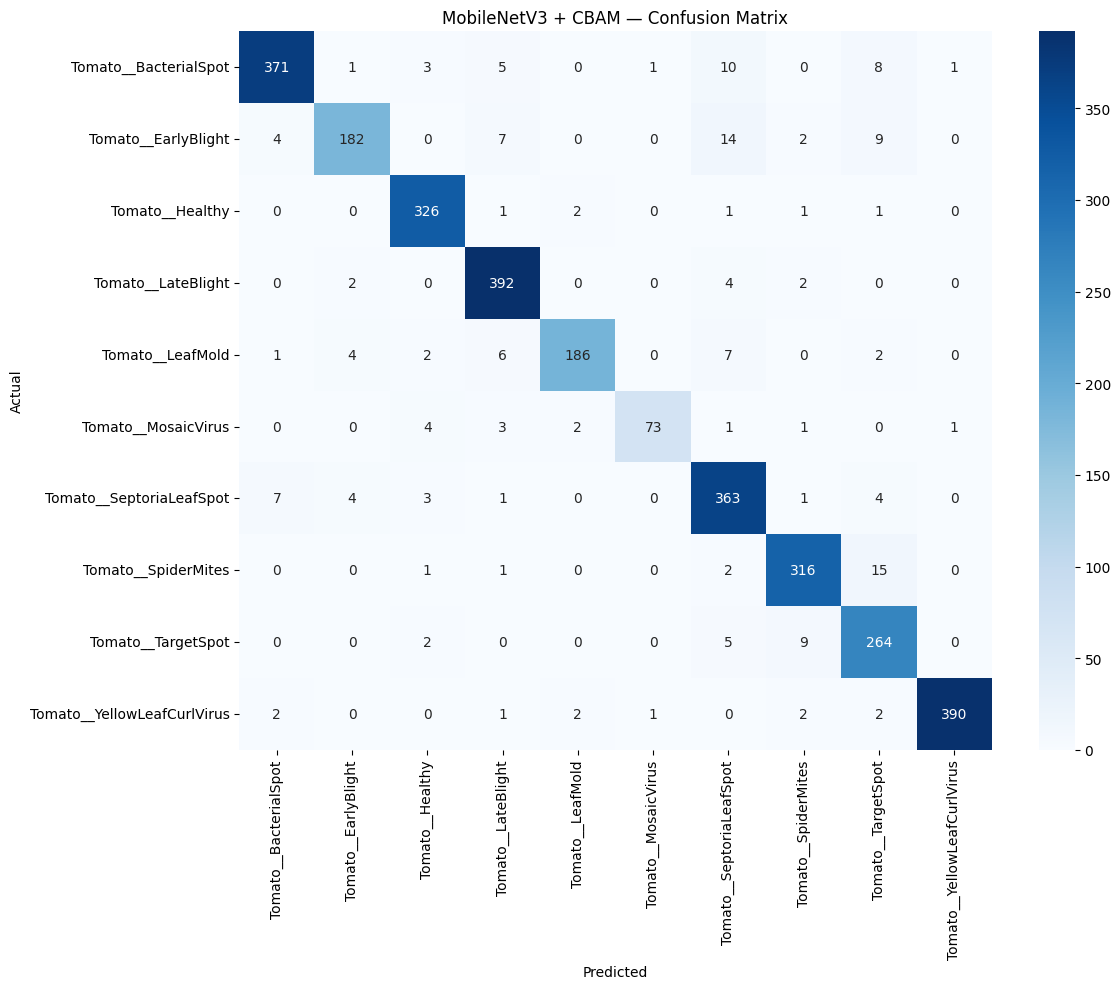

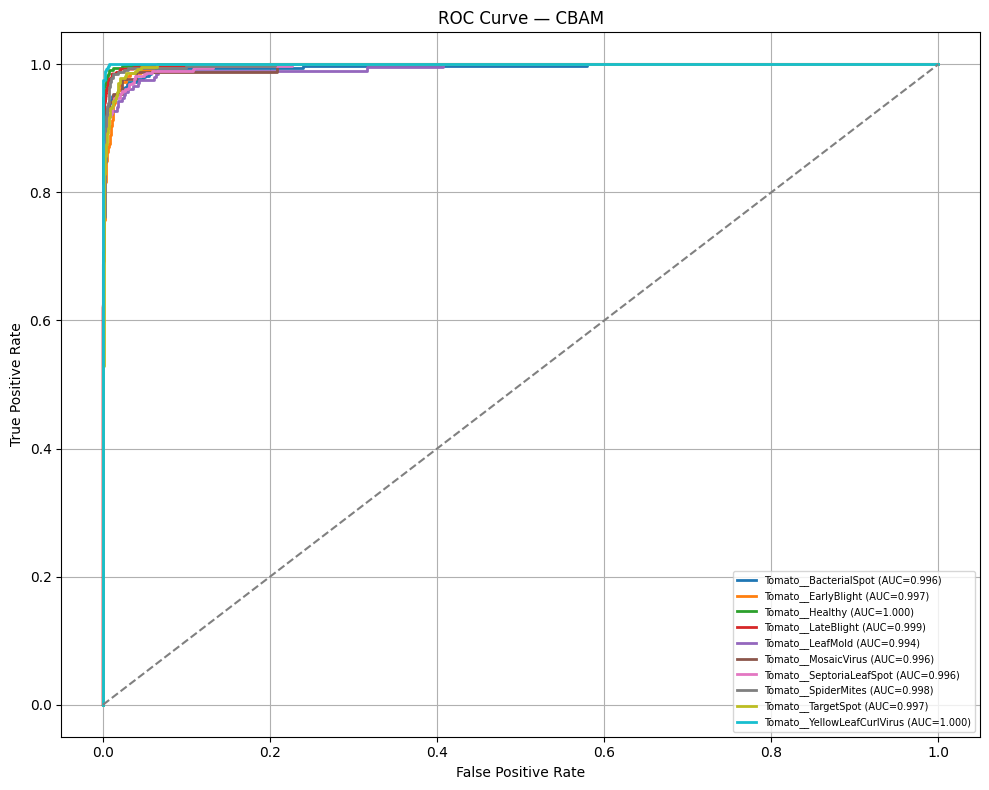

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397
1,MobileNetV3 + CA,0.941138,0.932517,0.940940
2,MobileNetV3 + SA,0.904965,0.892433,0.904386
3,MobileNetV3 + CBAM,0.941467,0.935287,0.941384


In [32]:
plot_training_curves(cbam_history, "CBAM", "cbam")

best_cbam_model = tf.keras.models.load_model(f"{WORK_DIR}/best_cbam_model.keras", safe_mode=False)

cbam_probs, cbam_row = evaluate_model(
    best_cbam_model, "MobileNetV3 + CBAM", "cbam", y_true, class_names
)
comparison_results.append(cbam_row)

plot_roc_curve(cbam_probs, y_true_bin, class_names, "CBAM", "cbam")

pd.DataFrame(comparison_results)


In [ ]:
cleanup("cbam_model", "cbam_backbone")
print("CBAM cleanup complete")


## 13. Model 5 — HECA (CBAM + Selective Backbone Fine-Tuning)

HECA reuses the CBAM block but additionally unfreezes the last 30 layers of the MobileNetV3Large backbone for fine-tuning, at a lower learning rate (`1e-4`) — this is the "selective fine-tuning" step from the paper design.

In [33]:
heca_model, heca_backbone = build_model(
    attention_fn=cbam_block,
    fine_tune_layers=HECA_UNFROZEN_LAYERS,
    learning_rate=HECA_LEARNING_RATE,
    name="heca"
)
heca_model.summary()


[heca] Trainable params: 1,835,909 | Non-trainable params: 1,401,632


Model: "heca"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_10[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ data_augmentatio… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 960)       │    116,160 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 960) │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_44         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_44[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_44[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 7, 7, 2)   │          0 │ lambda_4[0][0],   │
│ (Concatenate)       │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_45         │ (None, 7, 7, 960) │          0 │ multiply_44[0][0… │
│ (Multiply)          │                   │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_45[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 10)        │      9,610 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,541 (12.35 MB)

 Trainable params: 1,835,909 (7.00 MB)

 Non-trainable params: 1,401,632 (5.35 MB)

In [34]:
heca_history = train_or_resume(heca_model, "heca", "HECA")

histories["HECA"] = heca_history


[HECA] Training from scratch for up to 50 epochs...
Epoch 1/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.6504 - loss: 1.0978 - val_accuracy: 0.6879 - val_loss: 0.9424
Epoch 2/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.8950 - loss: 0.3123 - val_accuracy: 0.8020 - val_loss: 0.6129
Epoch 3/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9272 - loss: 0.2088 - val_accuracy: 0.8862 - val_loss: 0.3611
Epoch 4/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.9458 - loss: 0.1574 - val_accuracy: 0.9079 - val_loss: 0.2861
Epoch 5/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9576 - loss: 0.1200 - val_accuracy: 0.9346 - val_loss: 0.1998
Epoch 6/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.9645 - loss: 0.0993 - val_accuracy: 0.9444 - val_loss: 0.1636
Epoch 7/50
381/381 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - accuracy: 0.9727 - loss: 0.0787 - val_accuracy: 0.9408 - val_loss: 0.1844
Epoch 8/50
381/381 ━━━━━━━━━━━━━━━━━━━

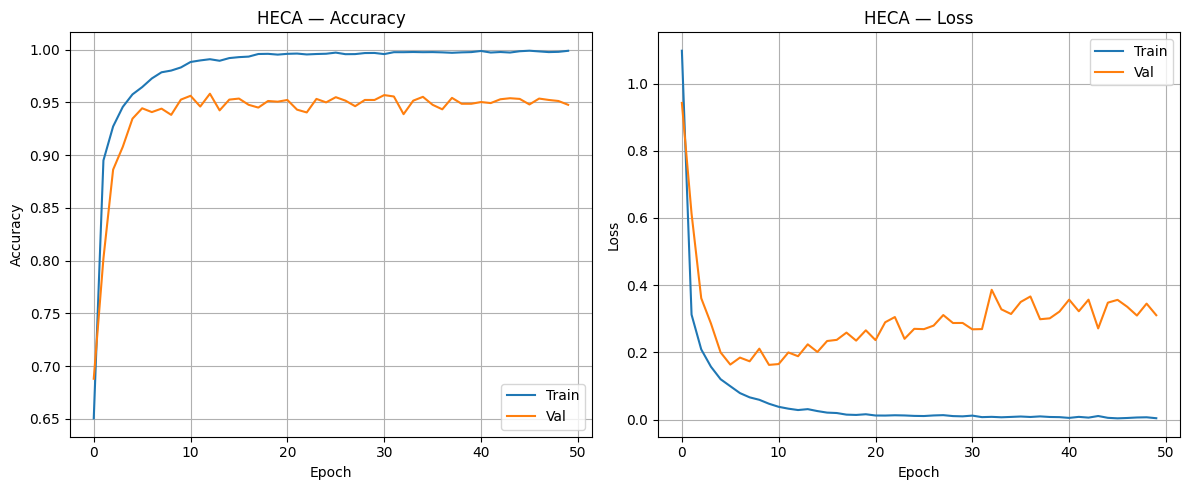

96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step
                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.96      0.95      0.96       400
        Tomato__EarlyBlight       0.94      0.88      0.91       218
            Tomato__Healthy       0.96      0.98      0.97       332
         Tomato__LateBlight       0.94      0.99      0.96       400
           Tomato__LeafMold       0.96      0.92      0.94       208
        Tomato__MosaicVirus       0.99      0.87      0.93        85
   Tomato__SeptoriaLeafSpot       0.94      0.96      0.95       383
        Tomato__SpiderMites       0.99      0.96      0.98       335
         Tomato__TargetSpot       0.93      0.98      0.95       280
Tomato__YellowLeafCurlVirus       0.99      0.98      0.98       400

                   accuracy                           0.96      3041
                  macro avg       0.96      0.95      0.95      3041
               weighted avg       0.96      0.96      0.96   

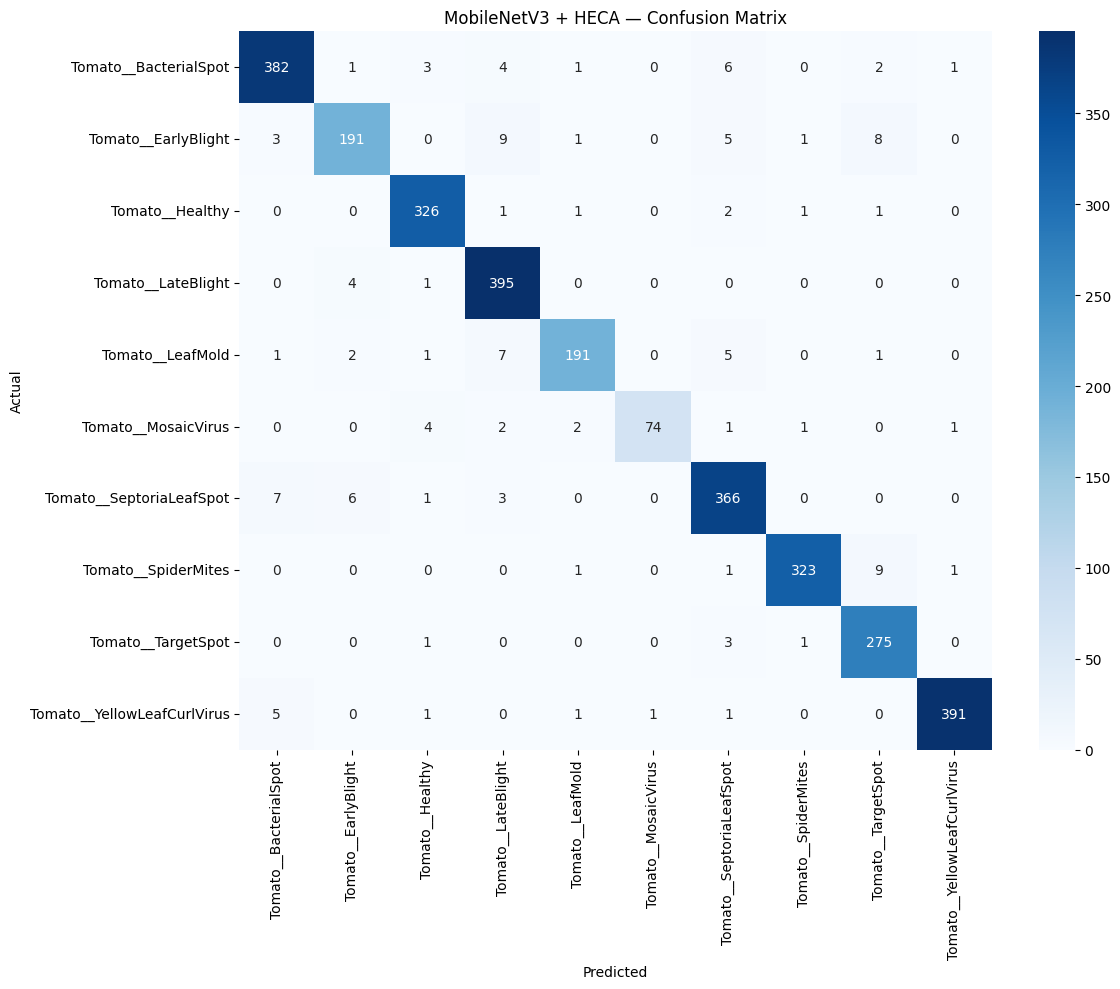

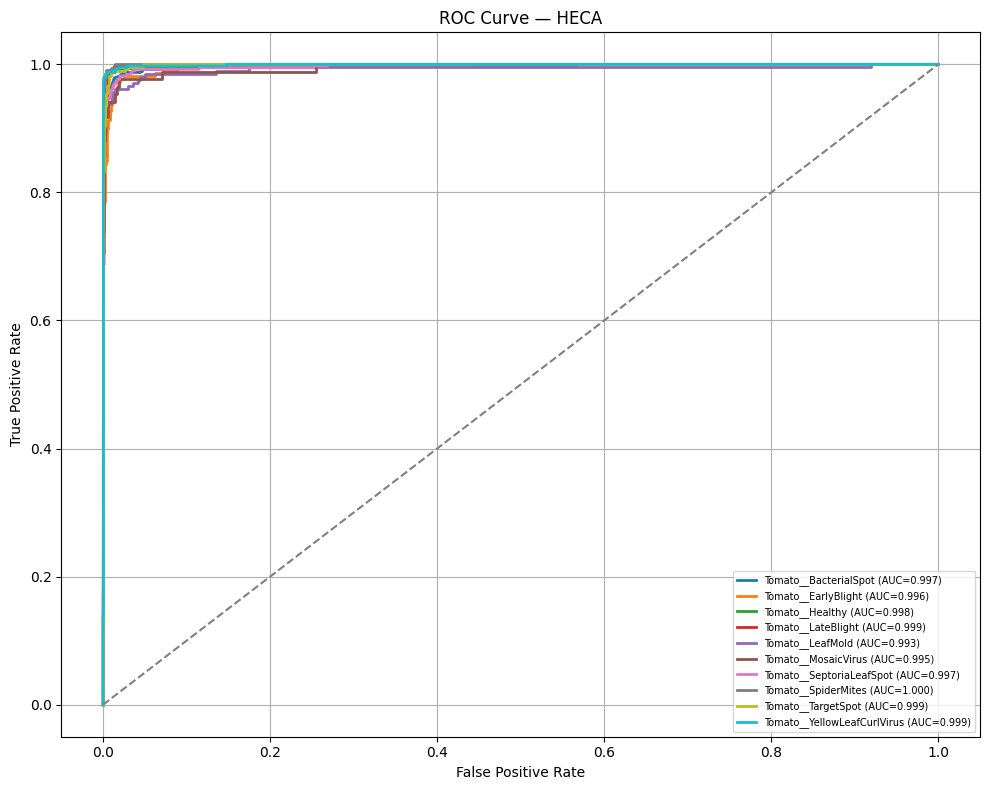

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397
1,MobileNetV3 + CA,0.941138,0.932517,0.940940
2,MobileNetV3 + SA,0.904965,0.892433,0.904386
3,MobileNetV3 + CBAM,0.941467,0.935287,0.941384
4,MobileNetV3 + HECA,0.958237,0.952641,0.958075


In [35]:
plot_training_curves(heca_history, "HECA", "heca")

best_heca_model = tf.keras.models.load_model(f"{WORK_DIR}/best_heca_model.keras", safe_mode=False)

heca_probs, heca_row = evaluate_model(
    best_heca_model, "MobileNetV3 + HECA", "heca", y_true, class_names
)
comparison_results.append(heca_row)

plot_roc_curve(heca_probs, y_true_bin, class_names, "HECA", "heca")

pd.DataFrame(comparison_results)


In [ ]:
cleanup("heca_model", "heca_backbone")
print("HECA cleanup complete")


## 14. Final Comparison Across All 5 Models

In [36]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df.to_csv(f"{WORK_DIR}/comparison_results.csv", index=False)
comparison_df


,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3 (Baseline),0.902006,0.892161,0.901397
1,MobileNetV3 + CA,0.941138,0.932517,0.940940
2,MobileNetV3 + SA,0.904965,0.892433,0.904386
3,MobileNetV3 + CBAM,0.941467,0.935287,0.941384
4,MobileNetV3 + HECA,0.958237,0.952641,0.958075


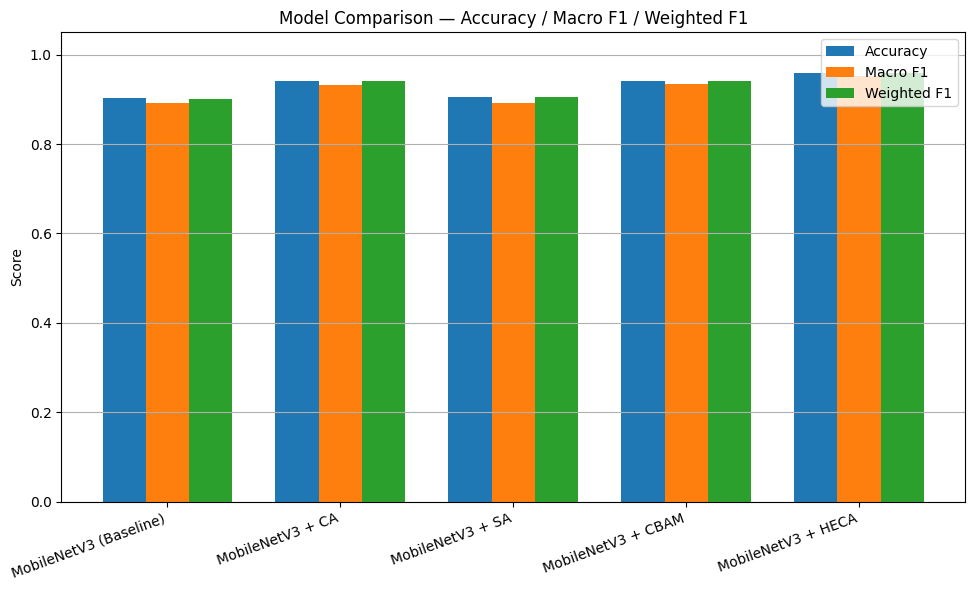

In [37]:
plt.figure(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.25

plt.bar(x - width, comparison_df["Accuracy"], width, label="Accuracy")
plt.bar(x,          comparison_df["Macro_F1"], width, label="Macro F1")
plt.bar(x + width,  comparison_df["Weighted_F1"], width, label="Weighted F1")

plt.xticks(x, comparison_df["Model"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Model Comparison — Accuracy / Macro F1 / Weighted F1")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()

plt.savefig(f"{WORK_DIR}/model_comparison_bars.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


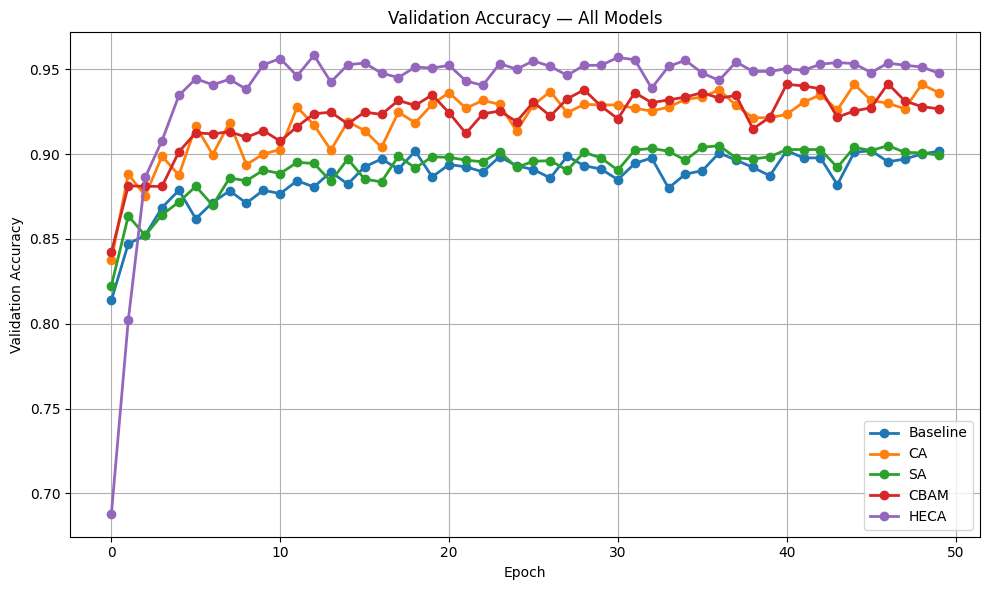

In [38]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], marker="o", linewidth=2, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy — All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"{WORK_DIR}/all_models_val_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


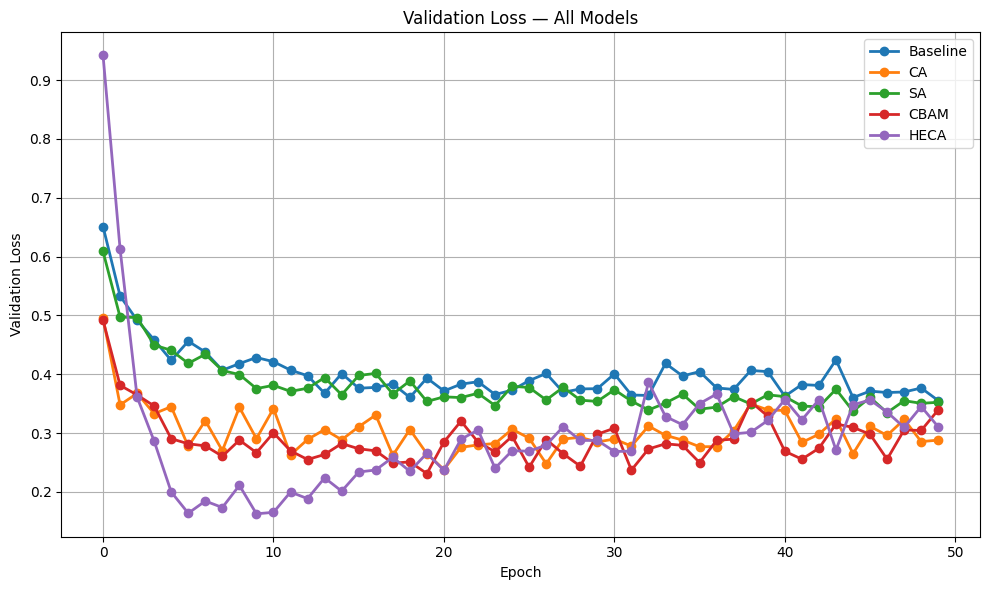

In [39]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history.history["val_loss"], marker="o", linewidth=2, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss — All Models")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(f"{WORK_DIR}/all_models_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## 15. Package All Artifacts for Download

In [ ]:
for f in sorted(os.listdir(WORK_DIR)):
    print(f)


In [ ]:
zip_path = f"{WORK_DIR}/tomato_attention_results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(WORK_DIR):
        fpath = os.path.join(WORK_DIR, fname)
        # skip the classification dataset copy and the zip itself
        if fname in ("tomato_classification", "tomato_attention_results.zip"):
            continue
        if os.path.isfile(fpath):
            zf.write(fpath, arcname=fname)

print("Archive created at:", zip_path)
print("Size (MB):", round(os.path.getsize(zip_path) / (1024 * 1024), 2))


## Summary

| Model | Attention | Backbone | Learning Rate |
|---|---|---|---|
| Baseline | none | frozen | 1e-3 |
| CA | Channel Attention | frozen | 1e-3 |
| SA | Spatial Attention | frozen | 1e-3 |
| CBAM | Channel + Spatial | frozen | 1e-3 |
| HECA | CBAM | last 30 layers unfrozen | 1e-4 |

All per-model artifacts (`.keras` models, training logs, classification reports, confusion matrices, accuracy/loss curves, ROC curves) plus the final `comparison_results.csv` are saved under `/kaggle/working/` and bundled into `tomato_attention_results.zip`.
